In [1]:
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import community as community_louvain

In [2]:
def find_dormant_cell(G, partition):
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    avg_size = np.mean([len(comm) for comm in communities.values()])
    w1, w2, w3, w4 = 0.35, 0.35, 0.15, 0.15
    suspicion_scores = []
    for comm_id, members in communities.items():
        if len(members) < 2:
            continue
        subgraph = G.subgraph(members)
        actual_edges = subgraph.number_of_edges()
        max_possible_edges = len(members) * (len(members) - 1) / 2
        internal_density = actual_edges / max_possible_edges if max_possible_edges > 0 else 0
        external_edges = 0
        for node in members:
            for neighbor in G.neighbors(node):
                if neighbor not in members:
                    external_edges += 1
        total_possible_external = len(members) * (G.number_of_nodes() - len(members))
        external_connectivity = external_edges / total_possible_external if total_possible_external > 0 else 0
        size_score = 1 - abs(len(members) - avg_size) / avg_size if avg_size > 0 else 0
        closeness_values = []
        for node in members:
            try:
                closeness_values.append(nx.closeness_centrality(G, node))
            except:
                closeness_values.append(0)
        avg_closeness = np.mean(closeness_values) if closeness_values else 0
        peripherality = 1 - avg_closeness
        suspicion = w1 * internal_density + w2 * (1 - external_connectivity) + w3 * size_score + w4 * peripherality
        suspicion_scores.append({'community_id': comm_id, 'suspicion_score': suspicion, 'members': list(members), 'internal_density': internal_density, 'external_connectivity': external_connectivity, 'size': len(members), 'peripherality': peripherality})
    if not suspicion_scores:
        return None
    most_suspicious = max(suspicion_scores, key=lambda x: x['suspicion_score'])
    reasoning = f"This community exhibits high internal density ({most_suspicious['internal_density']:.3f}), "
    reasoning += f"low external connectivity ({most_suspicious['external_connectivity']:.3f}), "
    reasoning += f"optimal size ({most_suspicious['size']} nodes), "
    reasoning += f"and peripheral positioning ({most_suspicious['peripherality']:.3f})."
    result = {'suspected_community_id': most_suspicious['community_id'], 'suspicion_score': most_suspicious['suspicion_score'], 'members': most_suspicious['members'], 'characteristics': {'internal_density': most_suspicious['internal_density'], 'external_connectivity': most_suspicious['external_connectivity'], 'size': most_suspicious['size'], 'peripherality': most_suspicious['peripherality']}, 'reasoning': reasoning, 'all_scores': suspicion_scores}
    return result

In [3]:
def visualize_dormant_cell(G, partition, dormant_result):
    fig = plt.figure(figsize=(18, 6))
    ax1 = plt.subplot(1, 3, 1)
    pos = nx.spring_layout(G, seed=42)
    dormant_members = set(dormant_result['members'])
    node_colors = ['red' if node in dormant_members else 'lightblue' for node in G.nodes()]
    nx.draw_networkx(G, pos, node_color=node_colors, node_size=300, with_labels=True, font_size=6, ax=ax1)
    ax1.set_title('Full Network with Dormant Cell')
    ax1.axis('off')
    ax2 = plt.subplot(1, 3, 2)
    subgraph = G.subgraph(dormant_members)
    sub_pos = nx.spring_layout(subgraph, seed=42)
    nx.draw_networkx(subgraph, sub_pos, node_color='red', node_size=500, with_labels=True, font_size=8, ax=ax2)
    ax2.set_title('Dormant Cell Subgraph')
    ax2.axis('off')
    ax3 = plt.subplot(1, 3, 3)
    all_scores = dormant_result['all_scores']
    comm_ids = [str(s['community_id']) for s in all_scores]
    scores = [s['suspicion_score'] for s in all_scores]
    colors_bar = ['red' if s['community_id'] == dormant_result['suspected_community_id'] else 'blue' for s in all_scores]
    ax3.barh(comm_ids, scores, color=colors_bar)
    ax3.set_xlabel('Suspicion Score')
    ax3.set_ylabel('Community ID')
    ax3.set_title('Suspicion Scores Comparison')
    plt.tight_layout()
    plt.savefig('figures/q6_dormant_cell_detection.png', dpi=300, bbox_inches='tight')
    plt.show()

OPERATION: DORMANT CELL DETECTION
Analyzing 6 detected communities...

DORMANT CELL DETECTED
Community ID: 4
Suspicion Score: 0.852/1.000

Members (6):
  Bamatabois, Chenildieu, Judge, Cochepaille, Brevet, Champmathieu

Characteristics:
  internal_density: 1.000
  external_connectivity: 0.019
  size: 6.000
  peripherality: 0.592

Analysis:
This community exhibits high internal density (1.000), low external connectivity (0.019), optimal size (6 nodes), and peripheral positioning (0.592).


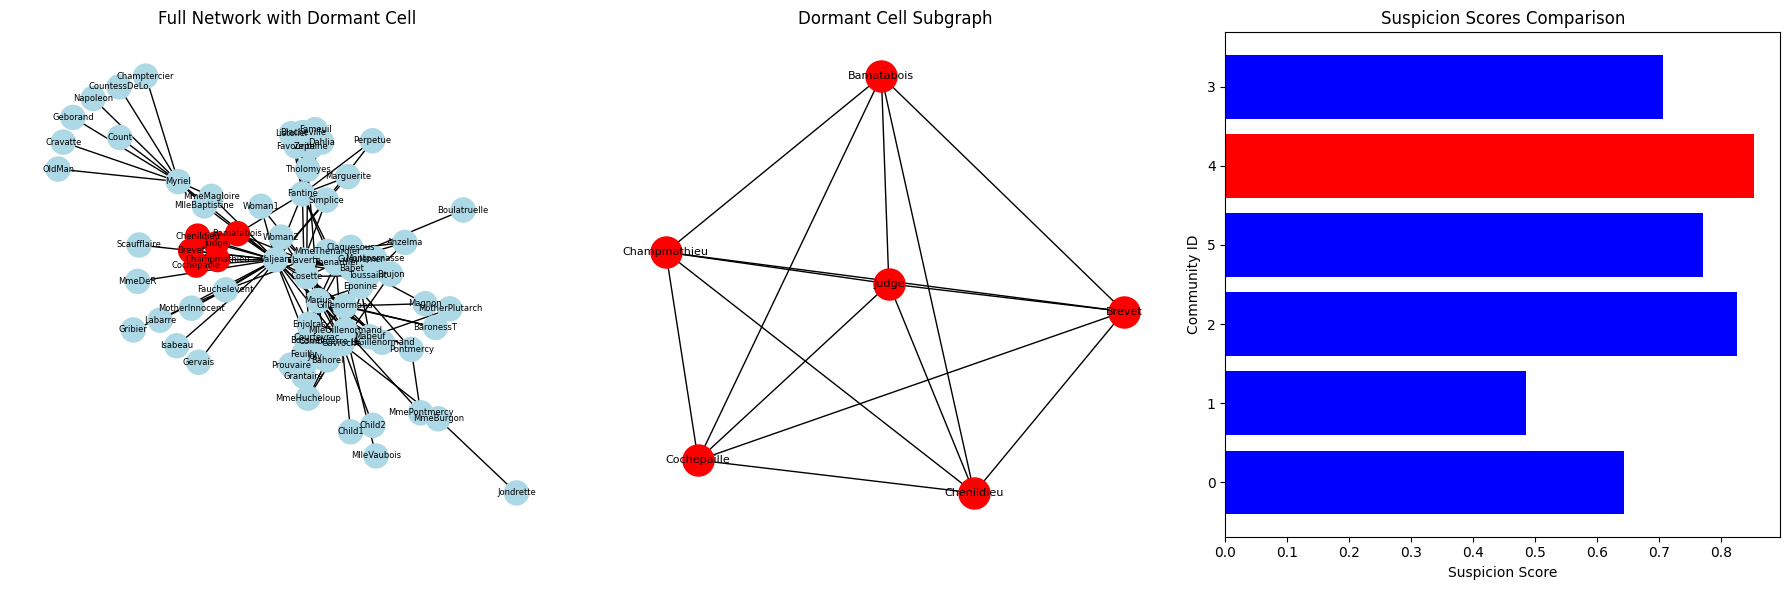

In [4]:
G = nx.les_miserables_graph()
print("=" * 80)
print("OPERATION: DORMANT CELL DETECTION")
print("=" * 80)
partition = community_louvain.best_partition(G)
print(f"Analyzing {len(set(partition.values()))} detected communities...")
dormant = find_dormant_cell(G, partition)
print("\n" + "=" * 80)
print("DORMANT CELL DETECTED")
print("=" * 80)
print(f"Community ID: {dormant['suspected_community_id']}")
print(f"Suspicion Score: {dormant['suspicion_score']:.3f}/1.000")
print(f"\nMembers ({len(dormant['members'])}):")
print(f"  {', '.join(dormant['members'][:10])}")
if len(dormant['members']) > 10:
    print(f"  ... and {len(dormant['members']) - 10} more")
print(f"\nCharacteristics:")
for key, value in dormant['characteristics'].items():
    print(f"  {key}: {value:.3f}")
print(f"\nAnalysis:")
print(dormant['reasoning'])
visualize_dormant_cell(G, partition, dormant)